# Evaluation & Comparison — Nukbah Project

**ARTI 308 – Machine Learning | Group #2**  
**Person 3 Responsibility:** Evaluation + Comparison

This notebook evaluates both models (Logistic Regression and Decision Tree) using:
- Accuracy
- Precision
- Recall
- Confusion Matrix

Then compares their performance in a summary table and visualizations.

## Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import numpy as np

## Step 2 — Load Dataset

Upload `riyadh_restaurants.csv` to Google Colab before running.

In [2]:
df = pd.read_csv('riyadh_restaurants.csv')

# Re-create target variable using median threshold
df = df.drop(columns=['Restaurant_Class'], errors='ignore')
threshold = df['rating'].median()
df['Restaurant_Class'] = (df['rating'] >= threshold).astype(int)

print('Dataset shape:', df.shape)
print('Threshold (median rating):', threshold)
print('\nClass distribution:')
print(df['Restaurant_Class'].value_counts())
df.head()

Dataset shape: (7294, 7)
Threshold (median rating): 7.7

Class distribution:
Restaurant_Class
1    3677
0    3617
Name: count, dtype: int64


,price,likes,tips,photos,ratingSignals,rating,Restaurant_Class
0,1,29.0,1,90,32.0,8.9,1
1,1,22.0,2,13,24.0,8.6,1
2,1,24.0,1,27,33.0,7.3,0
3,1,0.0,0,6,0.0,8.3,1
4,1,1.0,0,16,1.0,8.1,1


## Step 3 — Define Features and Target

In [3]:
features = ['price', 'likes', 'tips', 'photos', 'ratingSignals']
X = df[features]
y = df['Restaurant_Class']
print('Features shape:', X.shape)

Features shape: (7294, 5)


## Step 4 — Train / Test Split

Same split parameters as both models (80/20, stratified, random_state=42).

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training set size:', len(X_train))
print('Testing  set size:', len(X_test))

Training set size: 5835
Testing  set size: 1459


## Step 5 — Train Both Models

In [5]:
# Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

# Decision Tree
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

print('Both models trained successfully.')

Both models trained successfully.


## Step 6 — Generate Predictions

In [6]:
lr_pred       = lr_model.predict(X_test)
lr_train_pred = lr_model.predict(X_train)

dt_pred       = dt_model.predict(X_test)
dt_train_pred = dt_model.predict(X_train)

print('Predictions generated.')

Predictions generated.


## Step 7 — Compute Performance Metrics

In [7]:
# --- Logistic Regression ---
lr_train_acc = accuracy_score(y_train, lr_train_pred)
lr_acc       = accuracy_score(y_test,  lr_pred)
lr_prec      = precision_score(y_test, lr_pred)
lr_rec       = recall_score(y_test,    lr_pred)
lr_cm        = confusion_matrix(y_test, lr_pred)

# --- Decision Tree ---
dt_train_acc = accuracy_score(y_train, dt_train_pred)
dt_acc       = accuracy_score(y_test,  dt_pred)
dt_prec      = precision_score(y_test, dt_pred)
dt_rec       = recall_score(y_test,    dt_pred)
dt_cm        = confusion_matrix(y_test, dt_pred)

print('Metrics computed.')

Metrics computed.


## Step 8 — Print Detailed Results

### 8.1 Logistic Regression

In [8]:
print('='*55)
print('      LOGISTIC REGRESSION — RESULTS')
print('='*55)
print(f'  Train Accuracy : {lr_train_acc*100:.1f}%')
print(f'  Test  Accuracy : {lr_acc*100:.1f}%')
print(f'  Precision      : {lr_prec*100:.1f}%')
print(f'  Recall         : {lr_rec*100:.1f}%')
print('\nConfusion Matrix:')
print(lr_cm)
print('\nClassification Report:')
print(classification_report(
    y_test, lr_pred,
    target_names=['Lower Rated Restaurant', 'Highly Rated Restaurant']
))

      LOGISTIC REGRESSION — RESULTS
  Train Accuracy : 85.3%
  Test  Accuracy : 85.7%
  Precision      : 91.6%
  Recall         : 78.9%

Confusion Matrix:
[[670  53]
 [155 581]]

Classification Report:
                         precision    recall  f1-score   support

 Lower Rated Restaurant       0.81      0.93      0.87       723
Highly Rated Restaurant       0.92      0.79      0.85       736

               accuracy                           0.86      1459
              macro avg       0.86      0.86      0.86      1459
           weighted avg       0.86      0.86      0.86      1459



### 8.2 Decision Tree

In [9]:
print('='*55)
print('        DECISION TREE — RESULTS')
print('='*55)
print(f'  Train Accuracy : {dt_train_acc*100:.1f}%')
print(f'  Test  Accuracy : {dt_acc*100:.1f}%')
print(f'  Precision      : {dt_prec*100:.1f}%')
print(f'  Recall         : {dt_rec*100:.1f}%')
print('\nConfusion Matrix:')
print(dt_cm)
print('\nClassification Report:')
print(classification_report(
    y_test, dt_pred,
    target_names=['Lower Rated Restaurant', 'Highly Rated Restaurant']
))

        DECISION TREE — RESULTS
  Train Accuracy : 74.2%
  Test  Accuracy : 73.5%
  Precision      : 73.7%
  Recall         : 73.6%

Confusion Matrix:
[[530 193]
 [194 542]]

Classification Report:
                         precision    recall  f1-score   support

 Lower Rated Restaurant       0.73      0.73      0.73       723
Highly Rated Restaurant       0.74      0.74      0.74       736

               accuracy                           0.73      1459
              macro avg       0.73      0.73      0.73      1459
           weighted avg       0.73      0.73      0.73      1459



## Step 9 — Comparison Summary Table

In [10]:
comparison_df = pd.DataFrame({
    'Metric': ['Train Accuracy', 'Test Accuracy', 'Precision', 'Recall'],
    'Logistic Regression': [
        f'{lr_train_acc*100:.1f}%', f'{lr_acc*100:.1f}%',
        f'{lr_prec*100:.1f}%',      f'{lr_rec*100:.1f}%'
    ],
    'Decision Tree': [
        f'{dt_train_acc*100:.1f}%', f'{dt_acc*100:.1f}%',
        f'{dt_prec*100:.1f}%',      f'{dt_rec*100:.1f}%'
    ]
})

print('MODEL COMPARISON SUMMARY')
print('='*55)
print(comparison_df.to_string(index=False))

MODEL COMPARISON SUMMARY
        Metric Logistic Regression Decision Tree
Train Accuracy               85.3%         74.2%
 Test Accuracy               85.7%         73.5%
     Precision               91.6%         73.7%
        Recall               78.9%         73.6%


## Step 10 — Confusion Matrix Visualizations

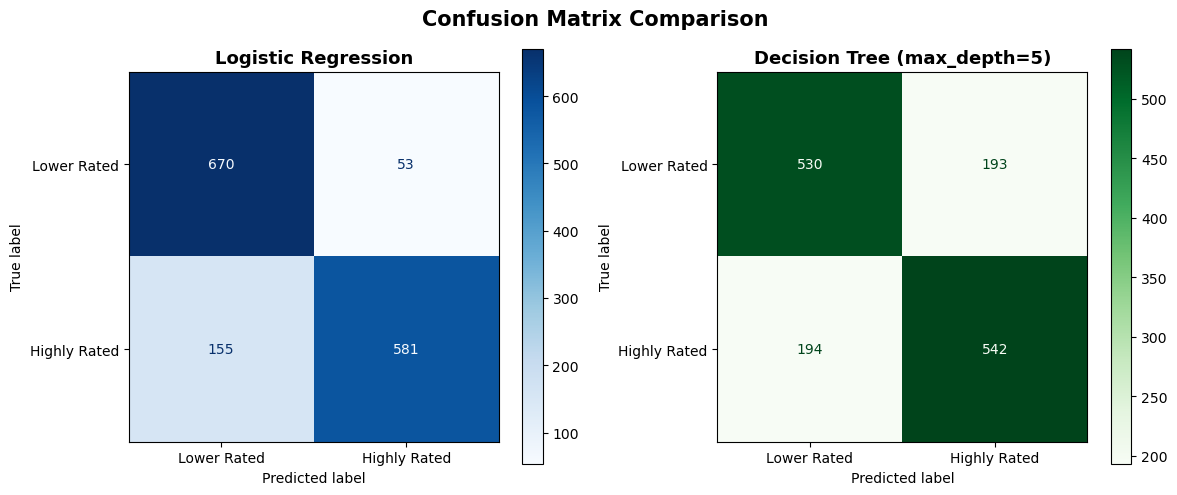

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Confusion Matrix Comparison', fontsize=15, fontweight='bold')

ConfusionMatrixDisplay.from_predictions(
    y_test, lr_pred,
    display_labels=['Lower Rated', 'Highly Rated'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Logistic Regression', fontsize=13, fontweight='bold')

ConfusionMatrixDisplay.from_predictions(
    y_test, dt_pred,
    display_labels=['Lower Rated', 'Highly Rated'],
    cmap='Greens', ax=axes[1]
)
axes[1].set_title('Decision Tree (max_depth=5)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 11 — Bar Chart: Metric Comparison

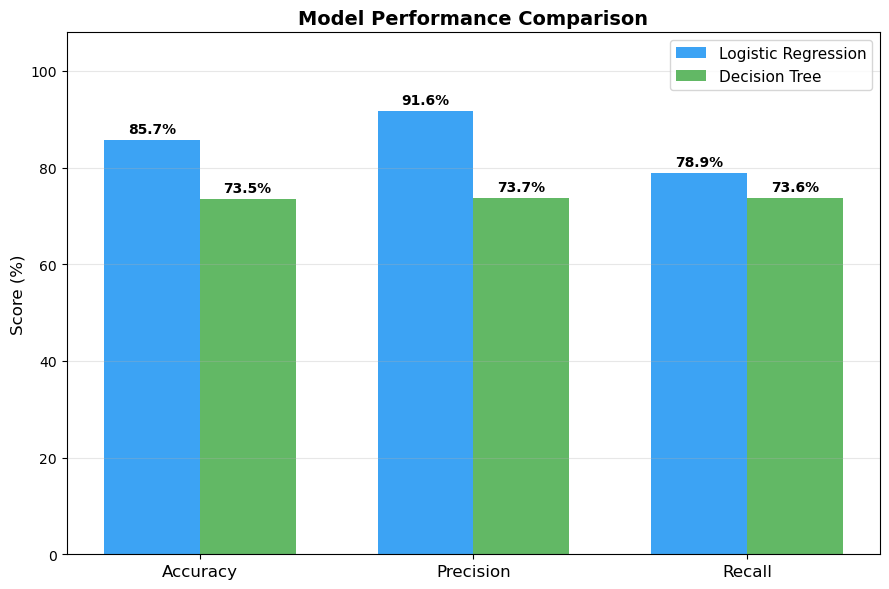

Evaluation & Comparison complete.


In [12]:
metrics_labels = ['Accuracy', 'Precision', 'Recall']
lr_vals = [lr_acc*100, lr_prec*100, lr_rec*100]
dt_vals = [dt_acc*100, dt_prec*100, dt_rec*100]

x = np.arange(len(metrics_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))
bars1 = ax.bar(x - width/2, lr_vals, width,
               label='Logistic Regression', color='#2196F3', alpha=0.88)
bars2 = ax.bar(x + width/2, dt_vals, width,
               label='Decision Tree',       color='#4CAF50', alpha=0.88)

ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels, fontsize=12)
ax.set_ylim(0, 108)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.annotate(f'{bar.get_height():.1f}%',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 5), textcoords='offset points',
                ha='center', fontsize=10, fontweight='bold')
for bar in bars2:
    ax.annotate(f'{bar.get_height():.1f}%',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 5), textcoords='offset points',
                ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Evaluation & Comparison complete.')